In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mohamedasak/chest-x-ray-6-classes-dataset")

# print("Path to dataset files:", path)

In [ ]:
import cv2
import numpy as np
import os
import glob
import subprocess
import tempfile
import re
from math import log
from joblib import Parallel, delayed
import glob


def image_to_point_cloud(image_path, output_txt_path, max_points=2000):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0
    
    edges = cv2.Canny(img, threshold1=50, threshold2=150)
    y_coords, x_coords = np.where(edges == 255)
    point_cloud = np.column_stack((x_coords, y_coords))
    
    if len(point_cloud) > max_points:
        indices = np.random.choice(len(point_cloud), max_points, replace=False)
        point_cloud = point_cloud[indices]
        
    if len(point_cloud) > 0:
        np.savetxt(output_txt_path, point_cloud, fmt='%.1f', delimiter=' ')
        
    return len(point_cloud)

def parse_ripser_stdout(stdout_text):
    persistence_diagrams = {0: [], 1: []}
    current_dim = None
    
    for line in stdout_text.splitlines():
        dim_match = re.search(r'persistence intervals in dim (\d+):', line)
        if dim_match:
            current_dim = int(dim_match.group(1))
            continue
            
        interval_match = re.search(r'\[(.*),(.*)\)', line)
        if interval_match and current_dim is not None and current_dim <= 1:
            birth = float(interval_match.group(1))
            death_str = interval_match.group(2).strip()
            
            if death_str != ')' and ' ' not in death_str:
                 try:
                     death = float(death_str)
                     persistence_diagrams[current_dim].append((birth, death))
                 except ValueError:
                     pass
    return persistence_diagrams

def calculate_persistent_entropy(diagram):
    entropies = []
    for dim in [0, 1]:
        intervals = diagram.get(dim, [])
        if not intervals:
            entropies.append(0.0)
            continue
            
        lifespans = [death - birth for birth, death in intervals if death > birth]
        sum_lifespan = sum(lifespans)
        
        if sum_lifespan == 0:
            entropies.append(0.0)
            continue
            
        entropy = -sum((l / sum_lifespan) * log(l / sum_lifespan) for l in lifespans if l > 0)
        entropies.append(entropy)
        
    return entropies


def extract_topological_stats(diagram):
    """Zwraca wektor 10 cech: [Count, Max, Mean, Variance, Entropy] dla H0 i H1"""
    features = []
    
    for dim in [0, 1]:
        intervals = diagram.get(dim, [])
        lifespans = [death - birth for birth, death in intervals if death > birth]
        
        if not lifespans:
            features.extend([0.0, 0.0, 0.0, 0.0, 0.0])
            continue
            
        count = len(lifespans)
        max_life = max(lifespans)
        mean_life = np.mean(lifespans)
        var_life = np.var(lifespans)
        sum_life = sum(lifespans)
        
        if sum_life > 0:
            entropy = -sum((l / sum_life) * log(l / sum_life) for l in lifespans if l > 0)
        else:
            entropy = 0.0
            
        features.extend([count, max_life, mean_life, var_life, entropy])
        
    return features

# W funkcji process_single_image podmieniasz:
# features = calculate_persistent_entropy(diagrams)
# na:
# features = extract_topological_stats(diagrams)

def extract_betti_curves(diagram, num_bins=50, max_filtration=150.0):
    """
    Przekształca diagram persystencji w Krzywe Bettiego dla H0 i H1.
    Zwraca wektor o długości 2 * num_bins (domyślnie 100).
    """
    betti_features = []
    
    # Tworzymy równomierną siatkę punktów (oś X filtracji)
    filtration_steps = np.linspace(0, max_filtration, num_bins)
    
    for dim in [0, 1]:
        intervals = diagram.get(dim, [])
        
        # Jeśli brak cech w danym wymiarze, dodajemy same zera
        if not intervals:
            betti_features.extend(np.zeros(num_bins).tolist())
            continue
            
        # Konwersja do tablicy NumPy dla szybkiego wektoryzowania
        intervals_arr = np.array(intervals)
        births = intervals_arr[:, 0]
        deaths = intervals_arr[:, 1]
        
        # Używamy tzw. broadcastingu w NumPy.
        # filtration_steps[:, np.newaxis] zamienia wektor 1D na kolumnę.
        # Sprawdzamy w jednym kroku, dla których kroków czasowych dana cecha żyła.
        steps_col = filtration_steps[:, np.newaxis]
        active_features = (steps_col >= births) & (steps_col < deaths)
        
        # Zliczamy aktywne cechy w każdym kroku (sumowanie wierszami)
        betti_curve = active_features.sum(axis=1)
        betti_features.extend(betti_curve.tolist())
        
    return betti_features


# # 4. Orkiestrator dla pojedynczego obrazu
# def process_single_image(img_path, label, ripser_path="./../../ripser/ripser"):
#     # Tworzymy bezpieczny, unikalny plik tymczasowy dla tego procesu
#     with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as temp_file:
#         temp_path = temp_file.name
        
#     try:
#         n_points = image_to_point_cloud(img_path, temp_path, max_points=2000)
        
#         # Zabezpieczenie przed pustymi/czarnymi zdjęciami
#         if n_points < 10: 
#             return [0.0, 0.0], label
            
#         # Odpalamy Ripsera i łapiemy wynik do pamięci (capture_output=True)
#         command = [ripser_path, "--format", "point-cloud", "--dim", "1", temp_path]
#         process = subprocess.run(command, capture_output=True, text=True)
        
#         # Parsowanie i ekstrakcja wektora
#         diagrams = parse_ripser_stdout(process.stdout)
#         features = calculate_persistent_entropy(diagrams)
        
#         return features, label
        
#     finally:
#         # Zawsze sprzątamy po sobie plik txt z dysku
#         if os.path.exists(temp_path):
#             os.remove(temp_path)


# 4. Orkiestrator dla pojedynczego obrazu
def process_single_image(img_path, label, ripser_path="./../../ripser/ripser"):
    # Tworzymy bezpieczny, unikalny plik tymczasowy dla tego procesu
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as temp_file:
        temp_path = temp_file.name
        
    try:
        n_points = image_to_point_cloud(img_path, temp_path, max_points=2000)
        

        # TODO to zabezpiecznei zal. od używanej funkcji ekstrakcji cech. 
        # Jeśli extract_topological_stats, to 10 cech, jeśli extract_betti_curves, to 100 cech. Dostosować w zależności od tego, którą funkcję finalnie wybierzesz.
        # Zabezpieczenie przed pustymi/czarnymi zdjęciami
        # if n_points < 10: 
        #     return [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], label
        if n_points < 10: 
              return [0.0] * 100, label
            
        # Odpalamy Ripsera i łapiemy wynik do pamięci (capture_output=True)
        command = [ripser_path, "--format", "point-cloud", "--dim", "1", temp_path]
        process = subprocess.run(command, capture_output=True, text=True)
        
        # Parsowanie i ekstrakcja wektora
        diagrams = parse_ripser_stdout(process.stdout)
        # features = extract_topological_stats(diagrams)
        features = extract_betti_curves(diagrams, num_bins=50, max_filtration=150.0)
        
        return features, label
        
    finally:
        # Zawsze sprzątamy po sobie plik txt z dysku
        if os.path.exists(temp_path):
            os.remove(temp_path)


# 5. Pętla główna (Zrównoleglenie na zbiór treningowy)
def process_dataset(dataset_dir, ripser_path, n_jobs=-1):
    classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
    tasks = []
    
    # Zbieranie ścieżek
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_dir, class_name)
        image_paths = glob.glob(os.path.join(class_dir, '*.*')) # .jpg lub .png
        for img_path in image_paths:
            tasks.append((img_path, label_idx))
            
    print(f"Znaleziono {len(tasks)} obrazów. Rozpoczynam wielowątkowe obliczenia...")
    
    # Odpalenie wszystkich zadań równolegle (n_jobs=-1 angażuje wszystkie dostępne rdzenie CPU)
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_image)(path, label, ripser_path) for path, label in tasks
    )
    
    # Rozpakowanie wyników
    X = [res[0] for res in results]
    y = [res[1] for res in results]
    
    return np.array(X), np.array(y)

# --- WYWOŁANIE ---
# X_train, y_train = process_dataset("dataset/train", ripser_path="./../../ripser/ripser")
# print(f"Kształt macierzy cech: {X_train.shape}")

In [22]:
# Szuka pierwszego pliku .jpg w folderze klasy Normal
real_images = glob.glob("dataset/train/Normal/*.jpg") 
# (np. "chest_xray/train/Normal/*.jpg" lub "dataset/train/Normal/*.jpeg")

if len(real_images) > 0:
    img_path = real_images[0]
    pc_path = "temp_point_cloud.txt"
    n_points = image_to_point_cloud(img_path, pc_path)
    print(f"Zapisano {n_points} punktów do {pc_path}")
else:
    print("Nie znaleziono żadnych zdjęć we wskazanym folderze!")




Zapisano 2000 punktów do temp_point_cloud.txt


In [23]:
X_train3, y_train3 = process_dataset("dataset/train", ripser_path="./../../ripser/ripser")
print(f"Kształt macierzy cech: {X_train3.shape}")

Znaleziono 14551 obrazów. Rozpoczynam wielowątkowe obliczenia...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   22.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (14551,) + inhomogeneous part.

In [24]:
%debug

> /tmp/ipykernel_328984/1774343087.py(229)process_dataset()
    227     y = [res[1] for res in results]
    228 
--> 229     return np.array(X), np.array(y)
    230 
    231 # --- WYWOŁANIE ---



In [25]:
X_fixed = []
y_fixed = []

for features, label in uratowane_wyniki:
    # Jeśli wektor jest za krótki (pusty obraz), wypełniamy go 100 zerami
    if len(features) != 100:
        features = [0.0] * 100
        
    X_fixed.append(features)
    y_fixed.append(label)

X_train3 = np.array(X_fixed)
y_train3 = np.array(y_fixed)

print(f"UDAŁO SIĘ! Kształt uratowanej macierzy cech: {X_train3.shape}")

UDAŁO SIĘ! Kształt uratowanej macierzy cech: (14551, 100)


In [27]:
# 100 kolumn, np. Betti_H0_0 ... Betti_H0_49, Betti_H1_0 ... Betti_H1_49
# Trenujemy Random Forest na nowym, potężniejszym wektorze
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


print("Trenowanie modelu Random Forest (Betti Curves)...")
clf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train3, y_train3, cv=cv, scoring='accuracy')

print(f"Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Trenowanie modelu Random Forest (Betti Curves)...
Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: 0.5709 (+/- 0.0164)


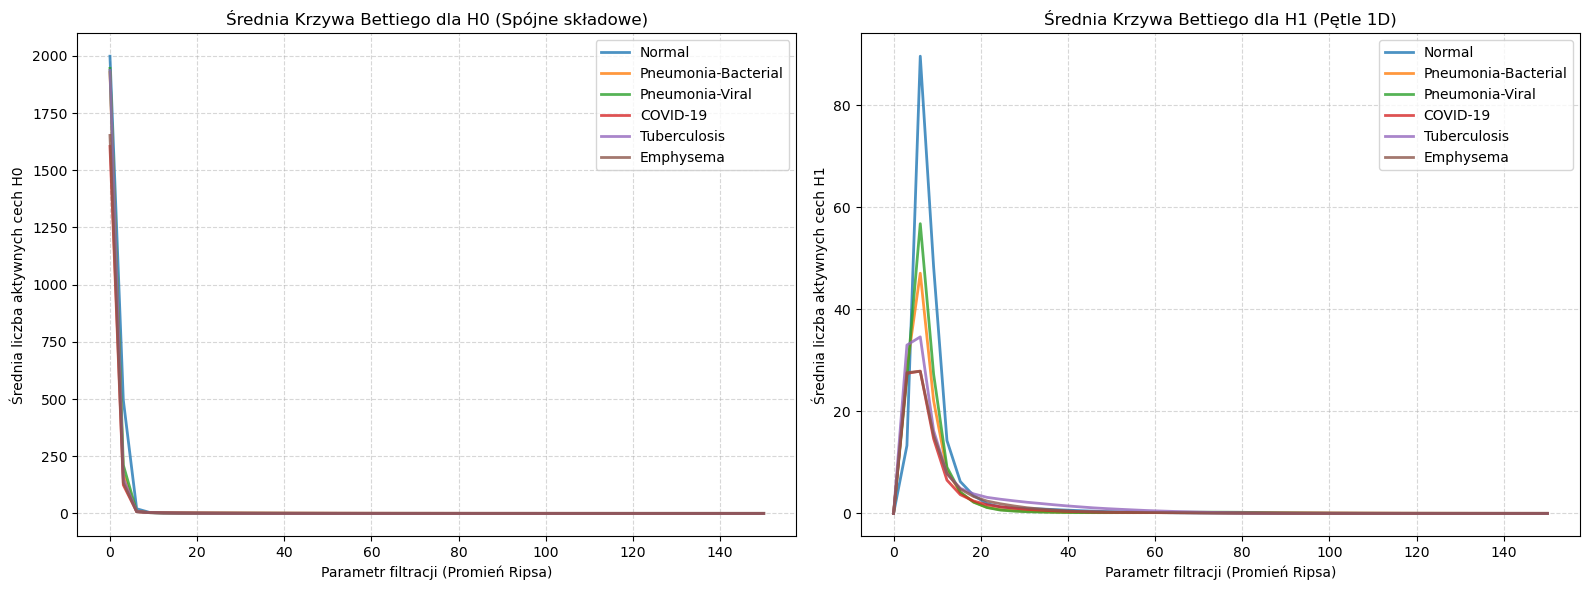

In [ ]:
import matplotlib.pyplot as plt

classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
num_bins = 50
max_filtration = 150.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_axis = np.linspace(0, max_filtration, num_bins)

for label_idx, class_name in enumerate(classes):
    # Filtrujemy dane dla konkretnej choroby
    class_data = X_train3[y_train3 == label_idx]
    
    # Wyliczamy uśredniony wektor dla całej klasy
    mean_curve = np.mean(class_data, axis=0)
    
    # Dzielimy wektor z powrotem na H0 i H1
    mean_h0 = mean_curve[:num_bins]
    mean_h1 = mean_curve[num_bins:]
    
    # Rysujemy
    axes[0].plot(x_axis, mean_h0, label=class_name, linewidth=2, alpha=0.8)
    axes[1].plot(x_axis, mean_h1, label=class_name, linewidth=2, alpha=0.8)

# Formatowanie wykresu H0
axes[0].set_title('Średnia Krzywa Bettiego dla H0 (Spójne składowe)')
axes[0].set_xlabel('Parametr filtracji (Promień Ripsa)')
axes[0].set_ylabel('Średnia liczba aktywnych cech H0')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Formatowanie wykresu H1
axes[1].set_title('Średnia Krzywa Bettiego dla H1 (Pętle 1D)')
axes[1].set_xlabel('Parametr filtracji (Promień Ripsa)')
axes[1].set_ylabel('Średnia liczba aktywnych cech H1')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/betti_curves_Lung_diseases.png", dpi=300)
plt.show()

Wczytano 276 poprawnych interwałów H1 z pliku.


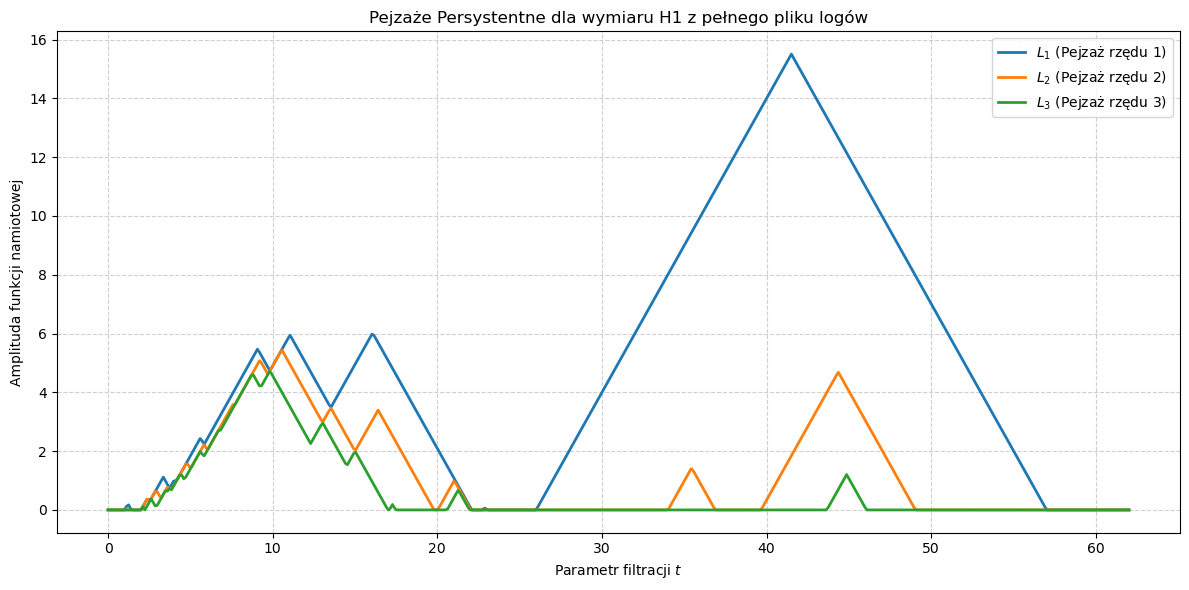

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# Ścieżka do Twojego pliku z logami (zmień jeśli plik jest gdzie indziej)
log_file_path = "ripser_output.log" 

if not os.path.exists(log_file_path):
    print(f"Błąd: Nie znaleziono pliku {log_file_path}. Sprawdź ścieżkę!")
else:
    intervals_h1 = []
    in_h1_section = False
    
    # 1. Wczytywanie i parsowanie całego pliku z dysku
    with open(log_file_path, 'r') as file:
        for line in file:
            # Szukamy początku sekcji H1
            if "persistence intervals in dim 1:" in line:
                in_h1_section = True
                continue
            # Jeśli natrafimy na kolejny wymiar (np. dim 2), przerywamy
            elif "persistence intervals in dim" in line and in_h1_section:
                in_h1_section = False
                
            # Wyciąganie interwałów H1
            if in_h1_section:
                match = re.search(r'\[(.*),(.*)\)', line)
                if match:
                    birth = float(match.group(1))
                    death_str = match.group(2).strip()
                    # Ignorujemy nieskończoności i puste wartości
                    if death_str != '' and ' ' not in death_str:
                        try:
                            intervals_h1.append([birth, float(death_str)])
                        except ValueError:
                            pass

    print(f"Wczytano {len(intervals_h1)} poprawnych interwałów H1 z pliku.")

    if len(intervals_h1) > 0:
        intervals_h1 = np.array(intervals_h1)

        # 2. Generowanie Pejzaży Persystentnych
        # Znajdujemy maksymalny czas życia, żeby dobrze dobrać oś X
        max_t = np.max(intervals_h1[:, 1]) + 5 
        t_vals = np.linspace(0, max_t, 500)
        
        b = intervals_h1[:, 0:1]
        d = intervals_h1[:, 1:2]
        t = t_vals[np.newaxis, :]

        # Funkcje namiotowe: max(0, min(t-b, d-t))
        tents = np.maximum(0, np.minimum(t - b, d - t))
        sorted_tents = np.sort(tents, axis=0)[::-1, :]

        # 3. Wizualizacja L1, L2, L3
        plt.figure(figsize=(12, 6))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

        for k in range(min(3, sorted_tents.shape[0])):
            plt.plot(t_vals, sorted_tents[k, :], label=f'$L_{k+1}$ (Pejzaż rzędu {k+1})', color=colors[k], linewidth=2)

        plt.title('Pejzaże Persystentne dla wymiaru H1 z pełnego pliku logów')
        plt.xlabel('Parametr filtracji $t$')
        plt.ylabel('Amplituda funkcji namiotowej')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Nie znaleziono żadnych pętli H1 do narysowania.")

Trwa wyliczanie uśrednionych pejzaży (po 10 zdjęć na klasę)...


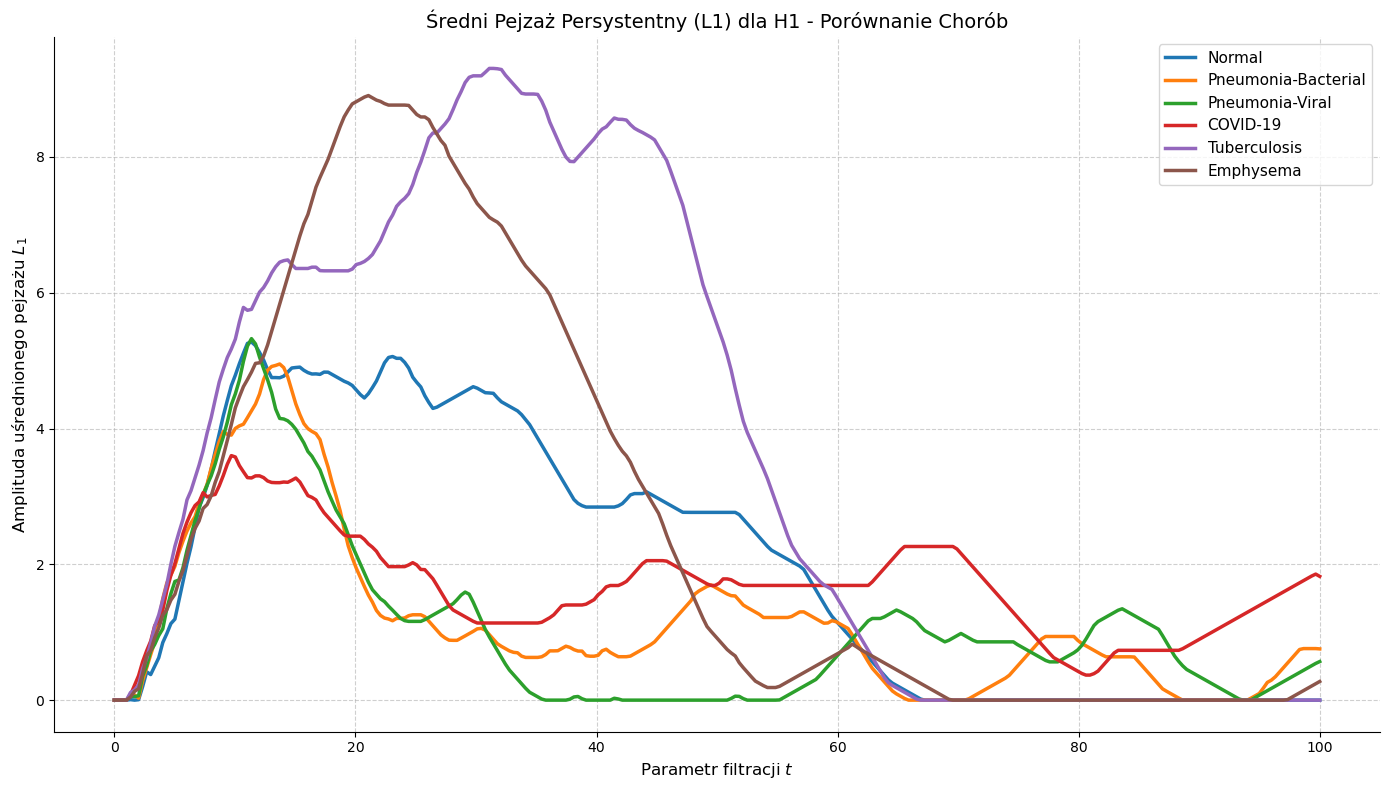

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import subprocess
import tempfile
import os
import cv2
import re

# Funkcja pomocnicza z naszego wcześniejszego potoku
def image_to_point_cloud(image_path, output_txt_path, max_points=2000):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return 0
    edges = cv2.Canny(img, threshold1=50, threshold2=150)
    y_coords, x_coords = np.where(edges == 255)
    point_cloud = np.column_stack((x_coords, y_coords))
    if len(point_cloud) > max_points:
        indices = np.random.choice(len(point_cloud), max_points, replace=False)
        point_cloud = point_cloud[indices]
    if len(point_cloud) > 0:
        np.savetxt(output_txt_path, point_cloud, fmt='%.1f', delimiter=' ')
    return len(point_cloud)

def parse_ripser_h1(stdout_text):
    intervals = []
    in_h1 = False
    for line in stdout_text.splitlines():
        if "persistence intervals in dim 1:" in line:
            in_h1 = True
            continue
        elif "persistence intervals in dim" in line and in_h1:
            in_h1 = False
            
        if in_h1:
            match = re.search(r'\[(.*),(.*)\)', line)
            if match:
                birth = float(match.group(1))
                death_str = match.group(2).strip()
                if death_str != '' and ' ' not in death_str:
                    try: intervals.append([birth, float(death_str)])
                    except ValueError: pass
    return np.array(intervals) if intervals else np.array([])

# --- WŁAŚCIWY KOD PORÓWNAWCZY ---
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
ripser_path = "./../../ripser/ripser"

plt.figure(figsize=(14, 8))
t_vals = np.linspace(0, 100, 300) # Oś X do promienia 100
t = t_vals[np.newaxis, :]

print("Trwa wyliczanie uśrednionych pejzaży (po 10 zdjęć na klasę)...")

for class_name in classes:
    # Pobieramy próbkę 10 zdjęć
    sample_paths = glob.glob(f"dataset/train/{class_name}/*.*")[:10]
    class_l1_landscapes = []
    
    for img_path in sample_paths:
        with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as temp_file:
            temp_path = temp_file.name
        try:
            n_points = image_to_point_cloud(img_path, temp_path, max_points=2000)
            if n_points >= 10:
                command = [ripser_path, "--format", "point-cloud", "--dim", "1", temp_path]
                process = subprocess.run(command, capture_output=True, text=True)
                intervals_h1 = parse_ripser_h1(process.stdout)
                
                if len(intervals_h1) > 0:
                    b, d = intervals_h1[:, 0:1], intervals_h1[:, 1:2]
                    tents = np.maximum(0, np.minimum(t - b, d - t))
                    # Wyciągamy L1 (najwyższą obwiednię)
                    L1 = np.sort(tents, axis=0)[::-1, :][0, :]
                    class_l1_landscapes.append(L1)
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)
                
    if class_l1_landscapes:
        # Uśredniamy L1 dla danej choroby
        mean_L1 = np.mean(class_l1_landscapes, axis=0)
        plt.plot(t_vals, mean_L1, label=class_name, linewidth=2.5)

plt.title('Średni Pejzaż Persystentny (L1) dla H1 - Porównanie Chorób', fontsize=14)
plt.xlabel('Parametr filtracji $t$', fontsize=12)
plt.ylabel('Amplituda uśrednionego pejzażu $L_1$', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import cv2
import os
import glob
import subprocess
import tempfile
import re
from joblib import Parallel, delayed

# --- 1. FUNKCJE POMOCNICZE ---

def image_to_point_cloud(image_path, output_txt_path, max_points=2000):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return 0
    edges = cv2.Canny(img, threshold1=50, threshold2=150)
    y_coords, x_coords = np.where(edges == 255)
    point_cloud = np.column_stack((x_coords, y_coords))
    if len(point_cloud) > max_points:
        indices = np.random.choice(len(point_cloud), max_points, replace=False)
        point_cloud = point_cloud[indices]
    if len(point_cloud) > 0:
        np.savetxt(output_txt_path, point_cloud, fmt='%.1f', delimiter=' ')
    return len(point_cloud)

def parse_ripser_full(stdout_text):
    diagrams = {0: [], 1: []}
    current_dim = None
    for line in stdout_text.splitlines():
        dim_match = re.search(r'persistence intervals in dim (\d+):', line)
        if dim_match:
            current_dim = int(dim_match.group(1))
            continue
        interval_match = re.search(r'\[(.*),(.*)\)', line)
        if interval_match and current_dim is not None and current_dim <= 1:
            birth = float(interval_match.group(1))
            death_str = interval_match.group(2).strip()
            if death_str != '' and ' ' not in death_str:
                try: diagrams[current_dim].append([birth, float(death_str)])
                except ValueError: pass
    return diagrams

def extract_landscapes(diagrams, num_bins=50, max_fil=100.0, num_pl=2):
    """Zwraca wektor 200 cech: L1 i L2 dla H0 oraz L1 i L2 dla H1"""
    t_vals = np.linspace(0, max_fil, num_bins)
    t = t_vals[np.newaxis, :]
    features = []
    
    for dim in [0, 1]:
        intervals = diagrams.get(dim, [])
        if not intervals:
            features.extend([0.0] * (num_bins * num_pl))
            continue
            
        arr = np.array(intervals)
        b, d = arr[:, 0:1], arr[:, 1:2]
        tents = np.maximum(0, np.minimum(t - b, d - t))
        sorted_tents = np.sort(tents, axis=0)[::-1, :]
        
        for k in range(num_pl):
            if k < sorted_tents.shape[0]:
                features.extend(sorted_tents[k, :].tolist())
            else:
                features.extend([0.0] * num_bins)
    return features

# --- 2. ORKIESTRATOR ---

def process_single_image_pl(img_path, label, ripser_path):
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as temp_file:
        temp_path = temp_file.name
    try:
        n_points = image_to_point_cloud(img_path, temp_path, max_points=2000)
        # Zabezpieczenie przed pustymi obrazami (2 wymiary * 2 pejzaże * 50 binów = 200 zer)
        if n_points < 10:
            return [0.0] * 200, label
            
        command = [ripser_path, "--format", "point-cloud", "--dim", "1", temp_path]
        process = subprocess.run(command, capture_output=True, text=True)
        
        diagrams = parse_ripser_full(process.stdout)
        features = extract_landscapes(diagrams, num_bins=50, max_fil=100.0, num_pl=2)
        return features, label
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

def run_full_pipeline(dataset_dir, output_prefix, ripser_path="./../../ripser/ripser", n_jobs=-1):
    classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
    tasks = []
    
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_dir, class_name)
        image_paths = glob.glob(os.path.join(class_dir, '*.*'))
        for img_path in image_paths:
            tasks.append((img_path, label_idx))
            
    print(f"[{output_prefix}] Rozpoczynam przetwarzanie {len(tasks)} obrazów...")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_image_pl)(path, label, ripser_path) for path, label in tasks
    )
    
    X = np.array([res[0] for res in results])
    y = np.array([res[1] for res in results])
    
    # Bezpieczny zapis na dysk!
    np.save(f"{output_prefix}_X.npy", X)
    np.save(f"{output_prefix}_y.npy", y)
    print(f"[{output_prefix}] Zakończono! Zapisano macierz o kształcie {X.shape} na dysk.")
    return X, y

# --- 3. ODPALENIE NA NOC ---
if __name__ == "__main__":
    RIPSER_BIN = "./../../ripser/ripser"
    
    # 1. Przetworzenie zbioru treningowego
    print(">>> START: Zbiór Treningowy <<<")
    X_train_pl, y_train_pl = run_full_pipeline("dataset/train", "TRAIN_LANDSCAPES", ripser_path=RIPSER_BIN)
    
    # Jeśli masz foldery val i test, możesz je od razu dopiąć do kolejki:
    if os.path.exists("dataset/val"):
        print("\n>>> START: Zbiór Walidacyjny <<<")
        X_val_pl, y_val_pl = run_full_pipeline("dataset/val", "VAL_LANDSCAPES", ripser_path=RIPSER_BIN)
        
    if os.path.exists("dataset/test"):
        print("\n>>> START: Zbiór Testowy <<<")
        X_test_pl, y_test_pl = run_full_pipeline("dataset/test", "TEST_LANDSCAPES", ripser_path=RIPSER_BIN)
        
    print("\nWSZYSTKIE OBLICZENIA ZAKOŃCZONE POMYŚLNIE. DOBRANOC!")

>>> START: Zbiór Treningowy <<<
[TRAIN_LANDSCAPES] Rozpoczynam przetwarzanie 14551 obrazów...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   24.6s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

[TRAIN_LANDSCAPES] Zakończono! Zapisano macierz o kształcie (14551, 200) na dysk.

>>> START: Zbiór Walidacyjny <<<
[VAL_LANDSCAPES] Rozpoczynam przetwarzanie 1748 obrazów...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   30.4s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

[VAL_LANDSCAPES] Zakończono! Zapisano macierz o kształcie (1748, 200) na dysk.

>>> START: Zbiór Testowy <<<
[TEST_LANDSCAPES] Rozpoczynam przetwarzanie 1737 obrazów...


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   28.6s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:   31.6s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   34.7s
[Paralle

[TEST_LANDSCAPES] Zakończono! Zapisano macierz o kształcie (1737, 200) na dysk.

WSZYSTKIE OBLICZENIA ZAKOŃCZONE POMYŚLNIE. DOBRANOC!


[Parallel(n_jobs=-1)]: Done 1737 out of 1737 | elapsed:  6.3min finished


Dane wczytane pomyślnie!
Kształt macierzy cech X: (14551, 200) (Powinno być ok. 14551 x 200)
Kształt etykiet y: (14551,)
--------------------------------------------------
Trenowanie modelu Random Forest na Pejzażach Persystentnych...
ŚREDNIA DOKŁADNOŚĆ (Accuracy): 0.5444 (+/- 0.0079)
--------------------------------------------------
Raport klasyfikacji (Precision, Recall, F1-Score):
                     precision    recall  f1-score   support

             Normal       0.63      0.86      0.73       534
Pneumonia-Bacterial       0.44      0.43      0.43       480
    Pneumonia-Viral       0.50      0.44      0.47       483
           COVID-19       0.44      0.41      0.42       484
       Tuberculosis       0.68      0.69      0.68       520
          Emphysema       0.47      0.36      0.41       410

           accuracy                           0.54      2911
          macro avg       0.53      0.53      0.52      2911
       weighted avg       0.53      0.54      0.53      2911


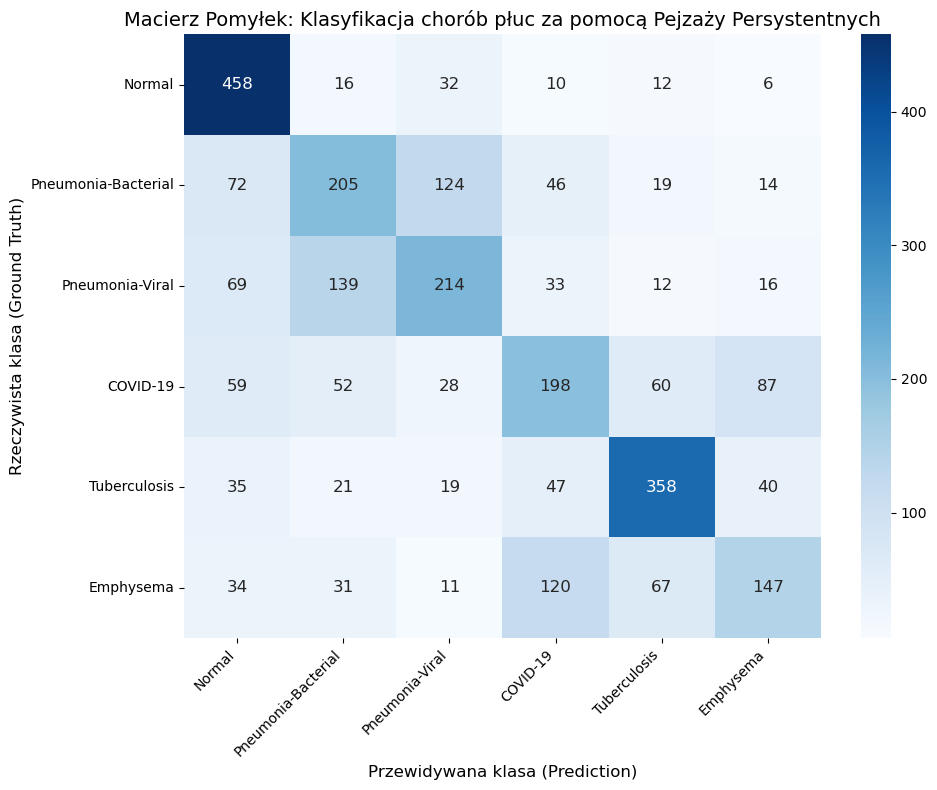

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Wczytanie nocnych łupów
# Upewnij się, że nazwy plików zgadzają się z tymi wygenerowanymi przez skrypt
X_train = np.load("TRAIN_LANDSCAPES_X.npy")
y_train = np.load("TRAIN_LANDSCAPES_y.npy")

print(f"Dane wczytane pomyślnie!")
print(f"Kształt macierzy cech X: {X_train.shape} (Powinno być ok. 14551 x 200)")
print(f"Kształt etykiet y: {y_train.shape}")
print("-" * 50)

# 2. Walidacja krzyżowa - ostateczny test skuteczności wektoryzacji pejzażami
print("Trenowanie modelu Random Forest na Pejzażach Persystentnych...")
clf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
print(f"ŚREDNIA DOKŁADNOŚĆ (Accuracy): {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
print("-" * 50)

# 3. Podział na zbiór testowy do głębszej analizy (Classification Report & Confusion Matrix)
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']

X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

clf.fit(X_t, y_t)
preds = clf.predict(X_v)

print("Raport klasyfikacji (Precision, Recall, F1-Score):")
print(classification_report(y_v, preds, target_names=classes))

# 4. Rysowanie Macierzy Pomyłek
cm = confusion_matrix(y_v, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 12})
plt.title('Macierz Pomyłek: Klasyfikacja chorób płuc za pomocą Pejzaży Persystentnych', fontsize=14)
plt.ylabel('Rzeczywista klasa (Ground Truth)', fontsize=12)
plt.xlabel('Przewidywana klasa (Prediction)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Wymiary załadowanych zbiorów:
Train: (14551, 200)
Val:   (1748, 200)
Test:  (1737, 200)
--------------------------------------------------
Trenowanie modelu Random Forest...
Dokładność na zbiorze WALIDACYJNYM: 0.5429 (54.3%)
Dokładność na zbiorze TESTOWYM:      0.5112 (51.1%)
--------------------------------------------------

Raport Klasyfikacji (Zbiór Testowy):
                     precision    recall  f1-score   support

             Normal       0.61      0.85      0.71       300
Pneumonia-Bacterial       0.48      0.40      0.44       300
    Pneumonia-Viral       0.46      0.43      0.44       300
           COVID-19       0.47      0.38      0.42       300
       Tuberculosis       0.60      0.59      0.60       287
          Emphysema       0.38      0.40      0.39       250

           accuracy                           0.51      1737
          macro avg       0.50      0.51      0.50      1737
       weighted avg       0.50      0.51      0.50      1737



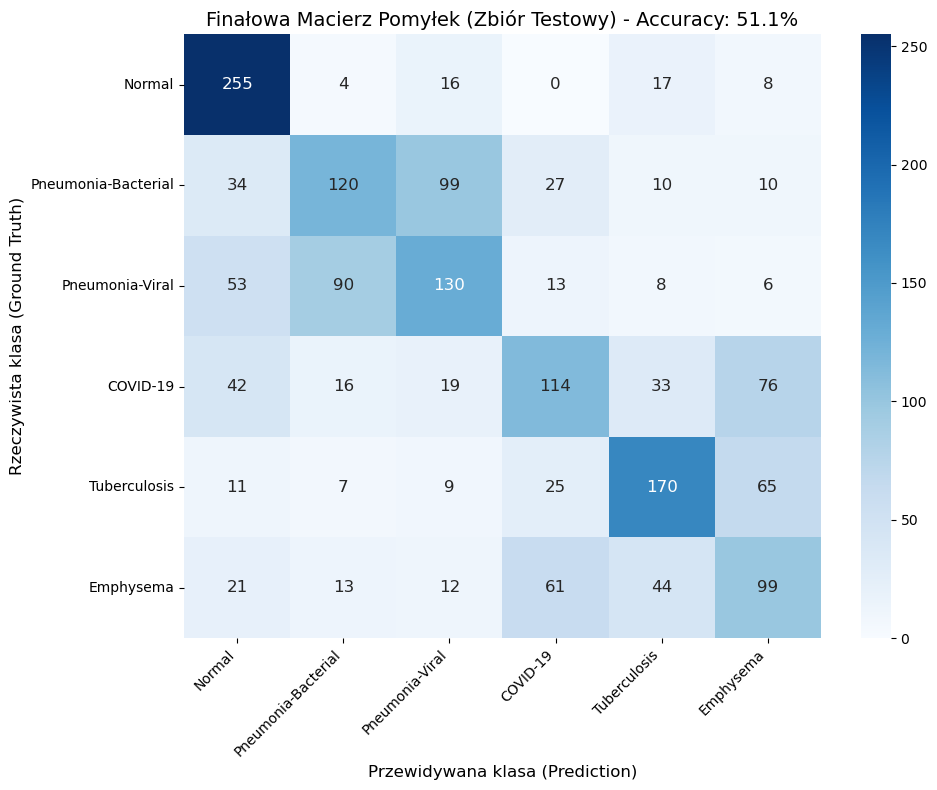

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Wczytanie wszystkich danych
X_train = np.load("TRAIN_LANDSCAPES_X.npy")
y_train = np.load("TRAIN_LANDSCAPES_y.npy")

X_val = np.load("VAL_LANDSCAPES_X.npy")
y_val = np.load("VAL_LANDSCAPES_y.npy")

X_test = np.load("TEST_LANDSCAPES_X.npy")
y_test = np.load("TEST_LANDSCAPES_y.npy")

print("Wymiary załadowanych zbiorów:")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print("-" * 50)

# 2. Trening ostatecznego modelu na danych treningowych
# class_weight='balanced' pomaga, jeśli jakaś choroba (np. Emphysema) ma trochę mniej próbek
print("Trenowanie modelu Random Forest...")
clf = RandomForestClassifier(n_estimators=500, max_depth=25, random_state=42, n_jobs=-1, class_weight='balanced')
clf.fit(X_train, y_train)

# 3. Szybkie sprawdzenie na zbiorze walidacyjnym
val_preds = clf.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print(f"Dokładność na zbiorze WALIDACYJNYM: {val_acc:.4f} ({(val_acc*100):.1f}%)")

# 4. WIELKI FINAŁ - Ocena na zbiorze TESTOWYM
test_preds = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"Dokładność na zbiorze TESTOWYM:      {test_acc:.4f} ({(test_acc*100):.1f}%)")
print("-" * 50)

# 5. Szczegółowy raport i macierz pomyłek dla zbioru testowego
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
print("\nRaport Klasyfikacji (Zbiór Testowy):")
print(classification_report(y_test, test_preds, target_names=classes))

# Rysowanie Macierzy
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 12})
plt.title(f'Finałowa Macierz Pomyłek (Zbiór Testowy) - Accuracy: {test_acc:.1%}', fontsize=14)
plt.ylabel('Rzeczywista klasa (Ground Truth)', fontsize=12)
plt.xlabel('Przewidywana klasa (Prediction)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

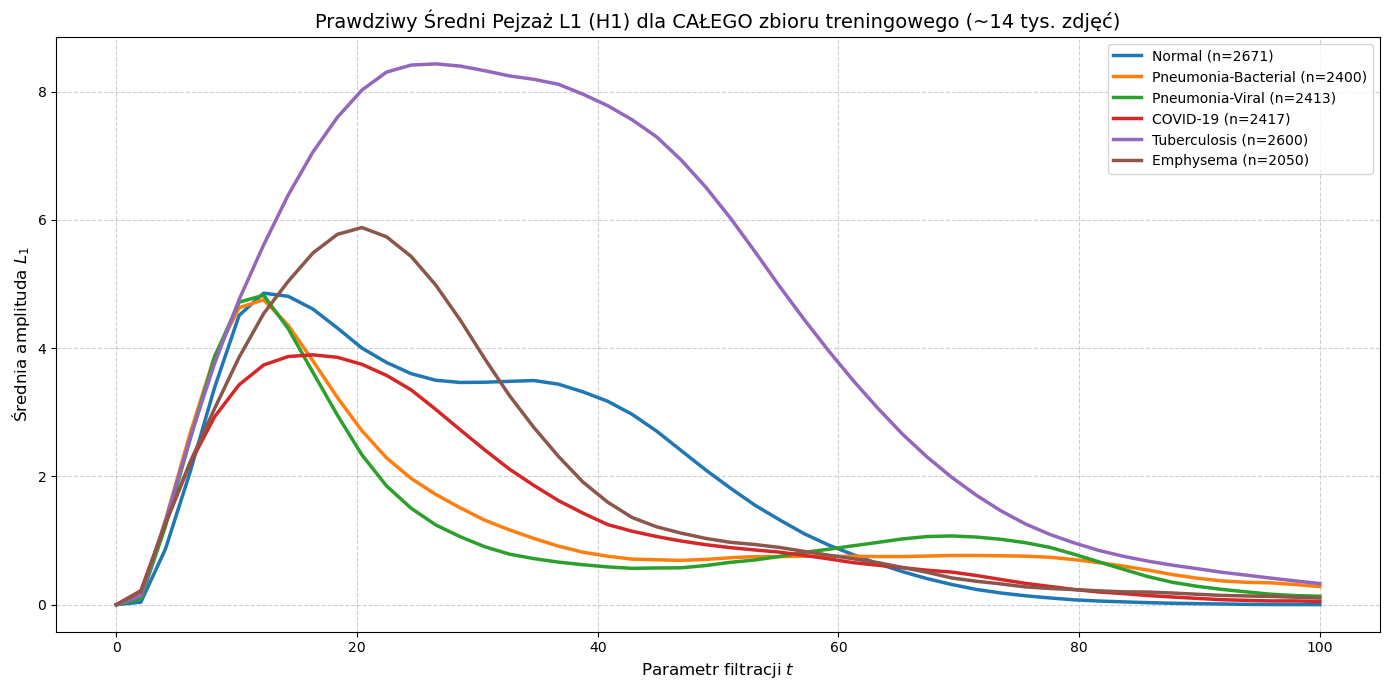

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Wczytanie danych treningowych
X_train = np.load("TRAIN_LANDSCAPES_X.npy")
y_train = np.load("TRAIN_LANDSCAPES_y.npy")
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']

plt.figure(figsize=(14, 7))
# Nasza oś X z nocnego skryptu: max_fil=100, num_bins=50
t_vals = np.linspace(0, 100, 50) 

for i, class_name in enumerate(classes):
    # Wyciągamy wszystkie wektory dla danej klasy (ok. 2400 pacjentów)
    class_data = X_train[y_train == i]
    
    # Liczymy średnią po wszystkich pacjentach (wzdłuż kolumn)
    mean_vector = np.mean(class_data, axis=0)
    
    # H1 L1 to indeksy od 100 do 149 w naszym 200-elementowym wektorze
    mean_H1_L1 = mean_vector[100:150]
    
    plt.plot(t_vals, mean_H1_L1, label=f"{class_name} (n={len(class_data)})", linewidth=2.5)

plt.title('Prawdziwy Średni Pejzaż L1 (H1) dla CAŁEGO zbioru treningowego (~14 tys. zdjęć)', fontsize=14)
plt.xlabel('Parametr filtracji $t$', fontsize=12)
plt.ylabel('Średnia amplituda $L_1$', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def extract_persistence_landscapes(diagram, num_bins=50, max_filtration=150.0, num_landscapes=2):
    """
    Zwraca wektor Pejzaży Persystentnych dla H0 i H1.
    Długość wektora = 2 (wymiary) * num_landscapes * num_bins
    """
    # Siatka wartości t
    t_vals = np.linspace(0, max_filtration, num_bins)
    pl_features = []
    
    for dim in [0, 1]:
        intervals = diagram.get(dim, [])
        if not intervals:
            # Wypełniamy zerami, jeśli brak cech
            pl_features.extend([0.0] * (num_bins * num_landscapes))
            continue
            
        intervals_arr = np.array(intervals)
        b = intervals_arr[:, 0:1] # Kształt (N, 1)
        d = intervals_arr[:, 1:2] # Kształt (N, 1)
        
        # Wektoryzacja t do kształtu (1, num_bins) dla broadcastingu
        t = t_vals[np.newaxis, :]
        
        # Wartości wszystkich funkcji namiotowych w jednym kroku: max(0, min(t-b, d-t))
        tent_vals = np.maximum(0, np.minimum(t - b, d - t))
        
        # Sortowanie malejąco po interwałach (oś 0)
        sorted_tents = np.sort(tent_vals, axis=0)[::-1, :]
        
        # Wyciąganie pejzaży rzędu k = 0, 1 ... (czyli L1, L2 ...)
        for k in range(num_landscapes):
            if k < sorted_tents.shape[0]:
                pl_features.extend(sorted_tents[k, :].tolist())
            else:
                # Jeśli jest mniej pętli niż k, pejzaż jest zerowy
                pl_features.extend([0.0] * num_bins)
                
    return pl_features



In [18]:
X_train2, y_train2 = process_dataset("dataset/train", ripser_path="./../../ripser/ripser")
print(f"Kształt macierzy cech: {X_train2.shape}")

Znaleziono 14551 obrazów. Rozpoczynam wielowątkowe obliczenia...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   23.3s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   25.7s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   28.6s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

Kształt macierzy cech: (14551, 10)


[Parallel(n_jobs=-1)]: Done 14551 out of 14551 | elapsed: 53.9min finished


In [12]:
X_train, y_train = process_dataset("dataset/train", ripser_path="./../../ripser/ripser")
print(f"Kształt macierzy cech: {X_train.shape}")

Znaleziono 14551 obrazów. Rozpoczynam wielowątkowe obliczenia...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

Kształt macierzy cech: (14551, 2)


[Parallel(n_jobs=-1)]: Done 14551 out of 14551 | elapsed: 61.2min finished


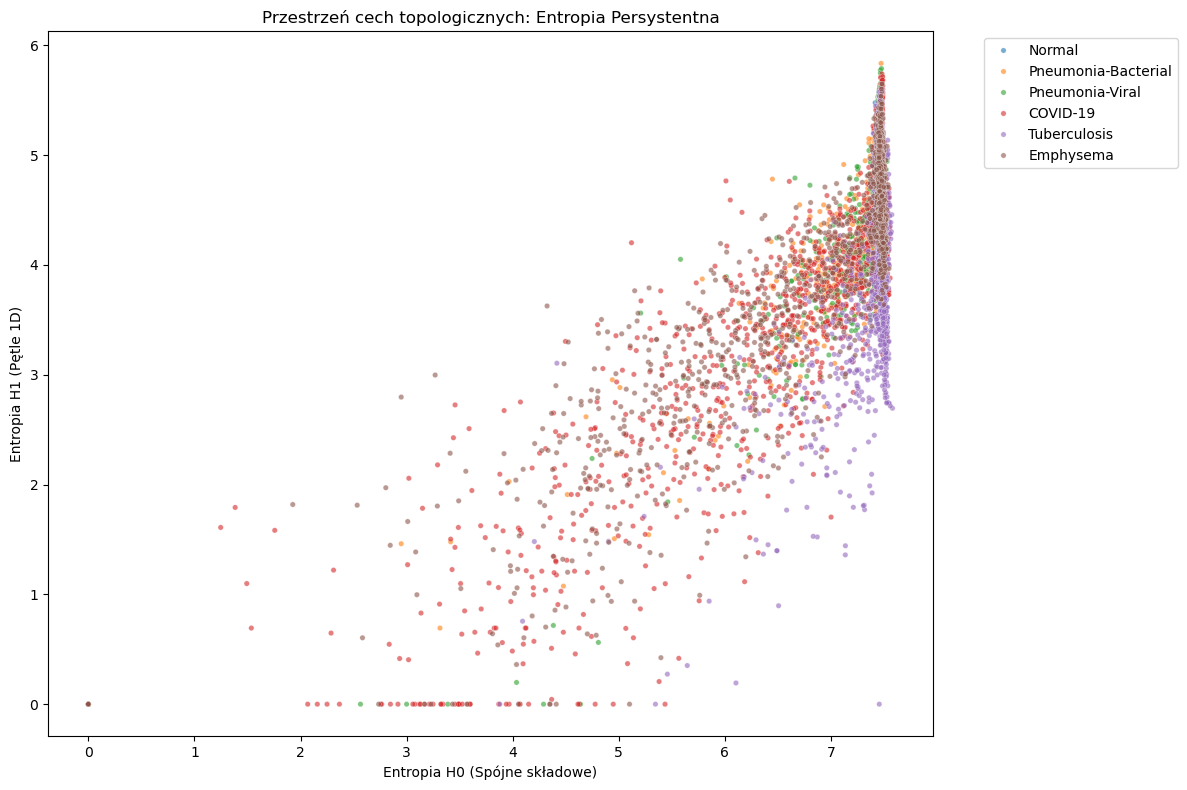

Trenowanie modelu Random Forest...
Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: 0.3538 (+/- 0.0224)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# 1. Wizualizacja cech 2D
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
df = pd.DataFrame(X_train, columns=['Entropy_H0', 'Entropy_H1'])
df['Label'] = [classes[label_idx] for label_idx in y_train]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Entropy_H0', 
    y='Entropy_H1', 
    hue='Label', 
    palette='tab10', 
    data=df, 
    alpha=0.6, 
    s=15
)
plt.title('Przestrzeń cech topologicznych: Entropia Persystentna')
plt.xlabel('Entropia H0 (Spójne składowe)')
plt.ylabel('Entropia H1 (Pętle 1D)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Trening bazowego modelu z walidacją krzyżową
print("Trenowanie modelu Random Forest...")
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Używamy 5-fold cross-validation, żeby rzetelnie ocenić model tylko na danych treningowych
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Opcjonalnie: fit na całym X_train, żeby mieć go gotowego do predykcji
clf.fit(X_train, y_train)

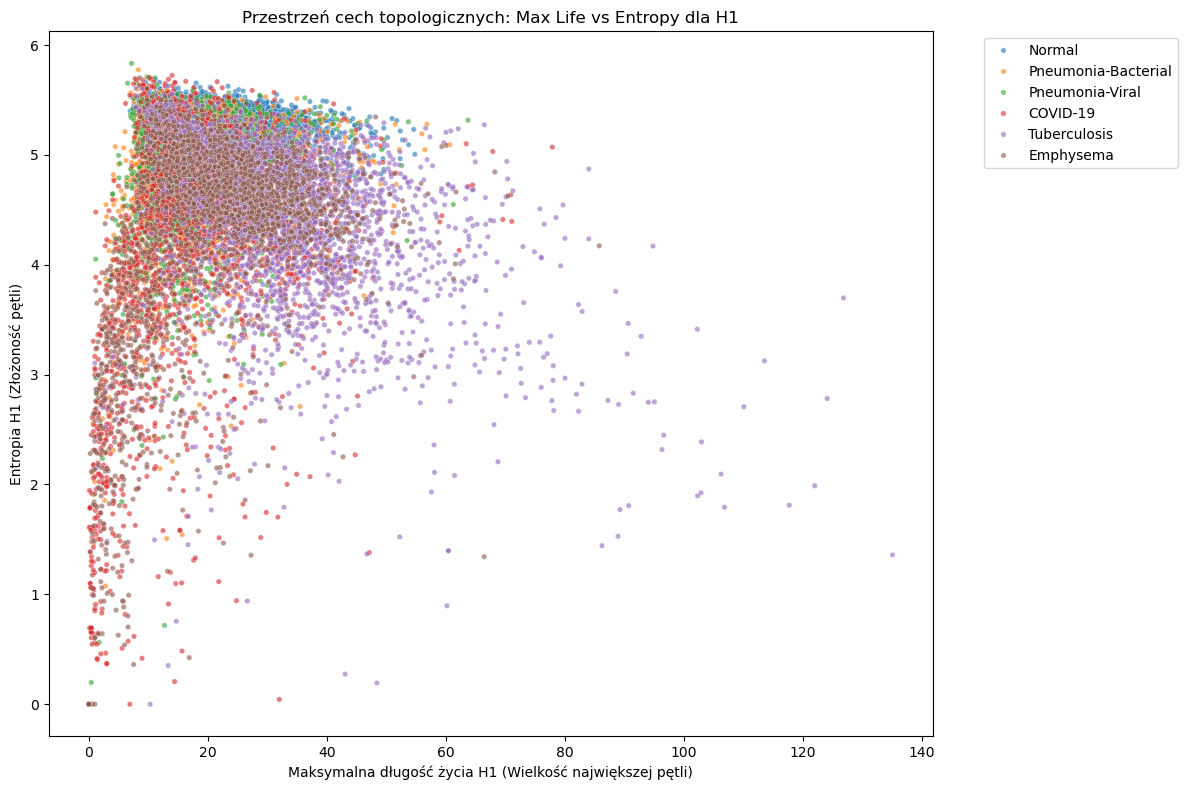

Trenowanie modelu Random Forest na 10 cechach topologicznych...
Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: 0.5341 (+/- 0.0120)


In [20]:

# 1. Definiujemy 10 nazw kolumn zgodnie z wyjściem funkcji
col_names = [
    'H0_Count', 'H0_Max_Life', 'H0_Mean_Life', 'H0_Var_Life', 'H0_Entropy',
    'H1_Count', 'H1_Max_Life', 'H1_Mean_Life', 'H1_Var_Life', 'H1_Entropy'
]

# 2. Tworzymy poprawny DataFrame
df = pd.DataFrame(X_train2, columns=col_names)
df['Label'] = [classes[label_idx] for label_idx in y_train2]

# 3. Wizualizacja (wybieramy 2 z 10 cech do pokazania na płaszczyźnie 2D)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='H1_Max_Life',  # Zmiana osi X
    y='H1_Entropy',   # Zmiana osi Y
    hue='Label', 
    palette='tab10', 
    data=df, 
    alpha=0.6, 
    s=15
)
plt.title('Przestrzeń cech topologicznych: Max Life vs Entropy dla H1')
plt.xlabel('Maksymalna długość życia H1 (Wielkość największej pętli)')
plt.ylabel('Entropia H1 (Złożoność pętli)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Kod treningowy zostaje bez zmian, użyje wszystkich 10 cech
print("Trenowanie modelu Random Forest na 10 cechach topologicznych...")
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train2, y_train2, cv=cv, scoring='accuracy')

print(f"Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import cross_val_score, StratifiedKFold
# from sklearn.metrics import classification_report, accuracy_score

# # 1. Wizualizacja cech 2D
# classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
# df = pd.DataFrame(X_train2, columns=['Entropy_H0', 'Entropy_H1'])
# df['Label'] = [classes[label_idx] for label_idx in y_train2]

# plt.figure(figsize=(12, 8))
# sns.scatterplot(
#     x='Entropy_H0', 
#     y='Entropy_H1', 
#     hue='Label', 
#     palette='tab10', 
#     data=df, 
#     alpha=0.6, 
#     s=15
# )
# plt.title('Przestrzeń cech topologicznych: Entropia Persystentna')
# plt.xlabel('Entropia H0 (Spójne składowe)')
# plt.ylabel('Entropia H1 (Pętle 1D)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# # 2. Trening bazowego modelu z walidacją krzyżową
# print("Trenowanie modelu Random Forest...")
# clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# # Używamy 5-fold cross-validation, żeby rzetelnie ocenić model tylko na danych treningowych
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(clf, X_train2, y_train2, cv=cv, scoring='accuracy')

# print(f"Średnia dokładność (Accuracy) w 5-krotnej walidacji krzyżowej: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# # Opcjonalnie: fit na całym X_train2, żeby mieć go gotowego do predykcji
# clf.fit(X_train2, y_train2)

In [ ]:
# import subprocess

# def run_ripser_cpp(points_file, dim=1, ripser_path="./../../ripser/ripser"):
#     log_file = "ripser_output.log"
#     stats_file = "ripser_stats.log"
    
#     # Budujemy komendę na podstawie Twojego skryptu bashowego
#     command = [
#         "/usr/bin/time", "-v", 
#         ripser_path, 
#         "--format", "point-cloud", 
#         "--dim", str(dim), 
#         points_file
#     ]
    
#     print("=== STEP 2: Run original Ripser (C++) ===")
    
#     # Przekierowanie stdout i stderr
#     with open(log_file, "w") as out_f, open(stats_file, "w") as err_f:
#         process = subprocess.run(command, stdout=out_f, stderr=err_f, text=True)
        
#     if process.returncode == 0:
#         print("Ripser zakończył działanie z sukcesem.")
#     else:
#         print("Błąd wykonania Ripsera.")
        
#     return log_file, stats_file

# # Wywołanie:
# log_file, stats_file = run_ripser_cpp(pc_path)

=== STEP 2: Run original Ripser (C++) ===
Ripser zakończył działanie z sukcesem.


In [ ]:
# import re
# from math import log

# def parse_ripser_log(log_path):
#     persistence_diagrams = {0: [], 1: []}
#     current_dim = None
    
#     with open(log_path, 'r') as f:
#         for line in f:
#             # Rozpoznanie zmiany wymiaru
#             dim_match = re.search(r'persistence intervals in dim (\d+):', line)
#             if dim_match:
#                 current_dim = int(dim_match.group(1))
#                 continue
                
#             # Wyciąganie interwałów: [birth, death)
#             interval_match = re.search(r'\[(.*),(.*)\)', line)
#             if interval_match and current_dim is not None and current_dim <= 1:
#                 birth = float(interval_match.group(1))
#                 death_str = interval_match.group(2).strip()
                
#                 # Ignorowanie nieskończoności (częsty zabieg przy feature extraction)
#                 if death_str != ')' and ' ' not in death_str: # Proste sprawdzenie na brak wartości
#                      try:
#                          death = float(death_str)
#                          persistence_diagrams[current_dim].append((birth, death))
#                      except ValueError:
#                          pass
    
#     return persistence_diagrams

# def calculate_persistent_entropy(diagram):
#     """Zwraca wektor cech: entropia dla H0 i H1"""
#     entropies = []
#     for dim in [0, 1]:
#         intervals = diagram.get(dim, [])
#         if not intervals:
#             entropies.append(0.0)
#             continue
            
#         lifespans = [death - birth for birth, death in intervals if death > birth]
#         sum_lifespan = sum(lifespans)
        
#         if sum_lifespan == 0:
#             entropies.append(0.0)
#             continue
            
#         # Entropia Shannona
#         entropy = -sum((l / sum_lifespan) * log(l / sum_lifespan) for l in lifespans if l > 0)
#         entropies.append(entropy)
        
#     return entropies # Zwraca np. [H0_entropy, H1_entropy]

# # Testowanie:
# diagrams = parse_ripser_log(log_file)
# features = calculate_persistent_entropy(diagrams)

# print(f"Cechy topologiczne (Entropia H0, H1): {features}")

Cechy topologiczne (Entropia H0, H1): [7.464208774436428, 4.838796694004215]


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Zakładając, że masz już zebrane X (lista wektorów cech) i y (etykiety klas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(classification_report(y_test, preds))

NameError: name 'X' is not defined